Lab 4 - Generating CDF's

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

****Q1****

**1.** 
Set up a grid of K equally spaced values between 0 and 1

In [103]:
K = 3
N = 5_000

x = np.arange(0, 1, 1/K).round(2)
y = np.arange(0, 1, 1/K).round(2)

xx, yy = np.meshgrid(x, y)


coords = list(zip(xx.reshape(-1), yy.reshape(-1)))
points = [f'Point{i}' for i in range(1, len(xx.reshape(-1)) + 1)]

df = pd.DataFrame({'Points': points, 'Coords': coords, 'X': xx.reshape(-1), 'Y': yy.reshape(-1)})
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

**2.**
Draw a point from the grid at random with equal probability

In [ ]:
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

**3.** For a very small K, repeat the above process n=5000 times, and plot the ECDF of the draws. 

Text(0.5, 1.0, 'Points as Tuples (x,y)\nK = 3')

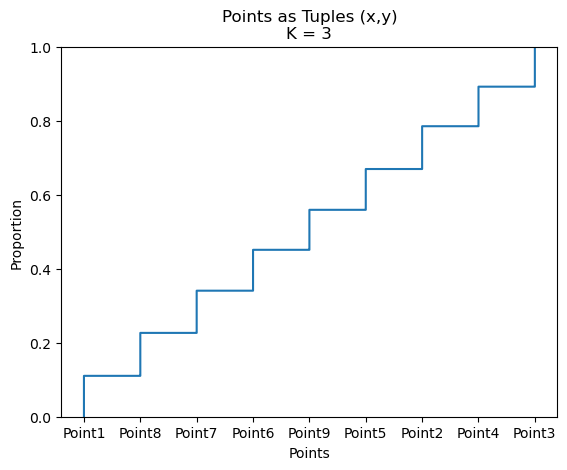

In [104]:
sns.ecdfplot(data = sampled_df, x='Points').set_title("Points as Tuples (x,y)\nK = 3")

Text(0.5, 1.0, 'Points as X coordinates (x)\nK = 3')

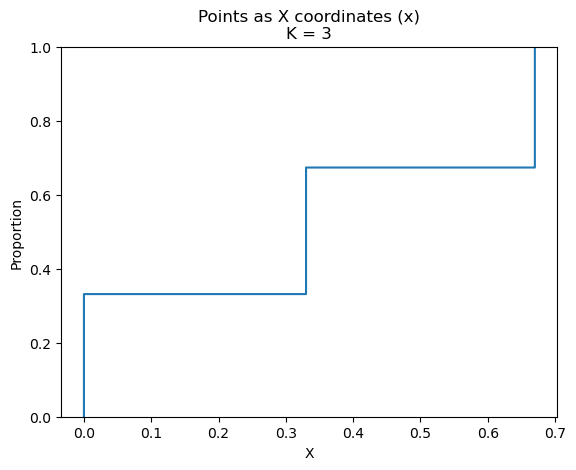

In [105]:
sns.ecdfplot(data = sampled_df, x='X').set_title("Points as X coordinates (x)\nK = 3")

Text(0.5, 1.0, 'Points as Y coordinates (y)\nK = 3')

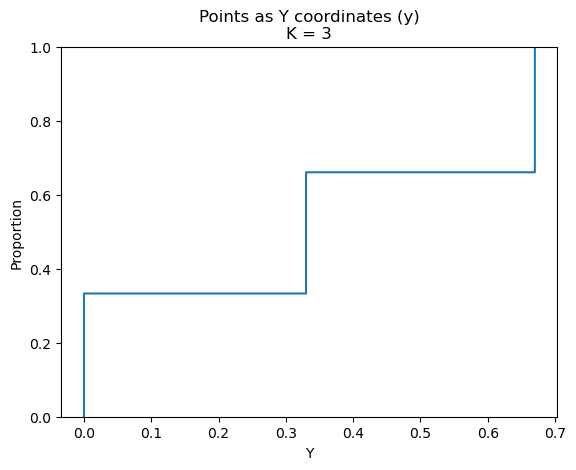

In [106]:
sns.ecdfplot(data = sampled_df, x='Y').set_title("Points as Y coordinates (y)\nK = 3")

**4.** What distribution does this approach as you increase K?

As K increases, the ECDF approaches the Uniform Distribution which presents as a straight positive line. 

In [107]:
K = 10
N = 5_000

x = np.arange(0, 1, 1/K).round(2)
y = np.arange(0, 1, 1/K).round(2)

xx, yy = np.meshgrid(x, y)


coords = list(zip(xx.reshape(-1), yy.reshape(-1)))
points = [f'Point{i}' for i in range(1, len(xx.reshape(-1)) + 1)]

df = pd.DataFrame({'Points': points, 'Coords': coords, 'X': xx.reshape(-1), 'Y': yy.reshape(-1)})
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

Text(0.5, 1.0, 'Points as Tuples (x,y)\nK = 10')

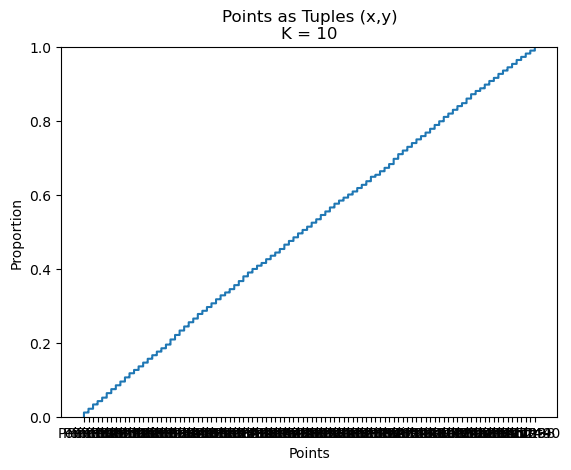

In [108]:
sns.ecdfplot(data = sampled_df, x='Points').set_title("Points as Tuples (x,y)\nK = 10")

Text(0.5, 1.0, 'Points as X coordinates (x)\nK = 10')

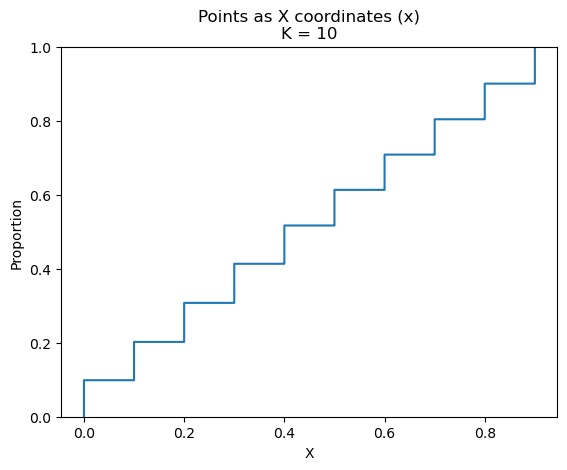

In [109]:
sns.ecdfplot(data = sampled_df, x='X').set_title("Points as X coordinates (x)\nK = 10")

Text(0.5, 1.0, 'Points as Y coordinates (y)\nK = 10')

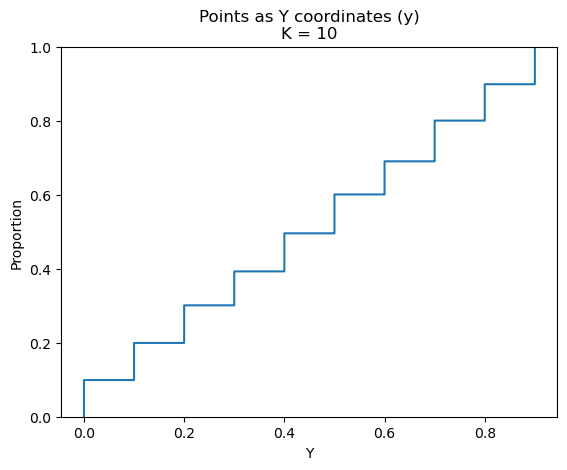

In [110]:
sns.ecdfplot(data = sampled_df, x='Y').set_title("Points as Y coordinates (y)\nK = 10")

Text(0.5, 1.0, 'Uniform CDF')

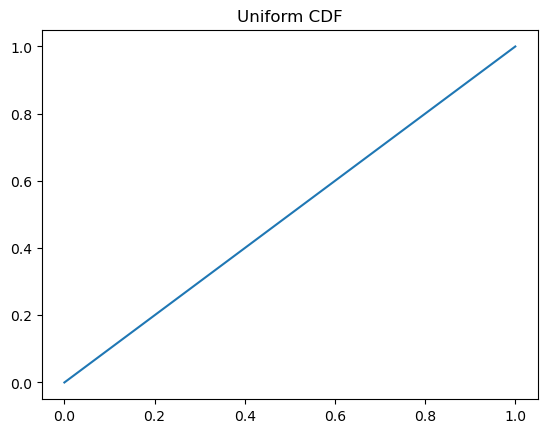

In [116]:
#Plot Uniform ECDF
from scipy.stats import uniform
x = np.linspace(0, 1, 100)
y = uniform.cdf(x, loc=0, scale = 1)

plt.plot(x, y)
plt.title("Uniform CDF")

****Q2****

**1.**
Draw n=32 values from uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of sqrt(+-3) ensures each draw has mean 0 and variance 1. 

In [146]:
rng = np.random.default_rng()
n = 32
x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
x

array([-1.47095327,  0.21229791,  1.12197507, -1.65919516,  0.96108308,
        1.7132915 , -1.69301665,  1.28113174, -0.94799411,  0.33067976,
        0.58277024, -1.50583401,  1.33724295, -1.61040567,  0.81030408,
        1.058532  , -0.60556036,  1.30969503,  0.69312646, -1.28043945,
       -1.49973901, -1.37917548,  0.3184922 , -0.53450438,  1.15077271,
       -0.42305133, -0.09643057, -0.37269173,  0.54508386, -0.8361068 ,
       -1.53331375, -0.28156858])

**2.** For this sample, compute the mean and multiply by np.sqrt(n).

In [147]:
x.mean() * np.sqrt(n)

np.float64(-0.7607588122573544)

**3.** Repeat the above process b = 5000 times and plot the ECDF.

In [148]:
b = 5_000
means = []
count = 0

while count < b:
    x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
    a = x.mean() * np.sqrt(n)
    means.append(a)
    count += 1


Text(0.5, 1.0, 'ECDF n = 32')

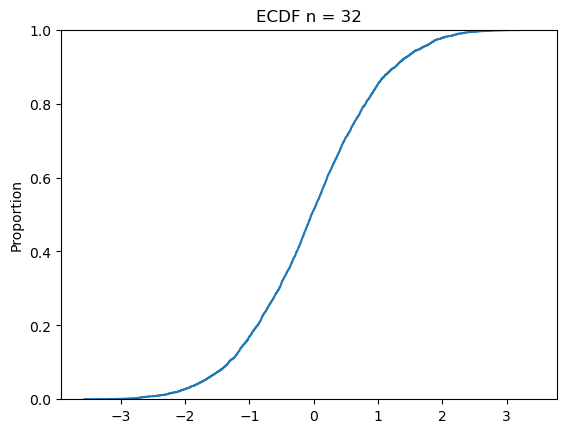

In [149]:
sns.ecdfplot(means)
plt.title("ECDF n = 32")

**4.** What distribution does this approach as n increases?

As n increases, the ECDF approaches the Normal distribution ECDF, which is S shaped. 

Text(0.5, 1.0, 'ECDF n = 100')

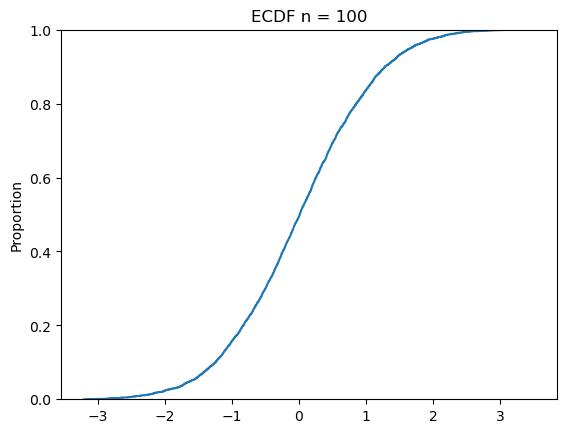

In [150]:
n = 100
b = 5_000
means = []
count = 0

while count < b:
    x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
    a = x.mean() * np.sqrt(n)
    means.append(a)
    count += 1

sns.ecdfplot(means)
plt.title("ECDF n = 100")

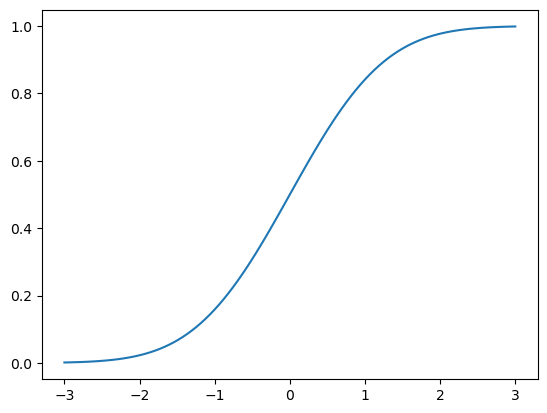

In [157]:
from scipy.stats import norm

x = np.linspace(-3, 3, 100)
y = norm.cdf(x)

plt.plot(x, y, label = 'Normal CDF')

****Q3****

**1.** Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability. 

In [175]:
n = 40
p = 1/2
outcomes = []
count = 0
while count < n:
    c = random.choice([0, 1])
    outcomes.append(c)
    count += 1

sum(outcomes), len(outcomes)

(17, 40)

**2.** From the final count of heads, subtract the expected number of heads

In [176]:
sum(outcomes) - (n*p)

-3.0

**3.** Divide by the standard deviation sqrt(n*p*(1-p))

In [177]:
(sum(outcomes) - (n*p))/(np.sqrt(n*p*(1-p)))

np.float64(-0.9486832980505138)

**4.** Repeat above process b = 5000 times and plot the ECDF

In [204]:
heads = []
p = 1/2
q = 1-p
b = 5_000
n = 40

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)



Text(0.5, 1.0, 'ECDF Coins')

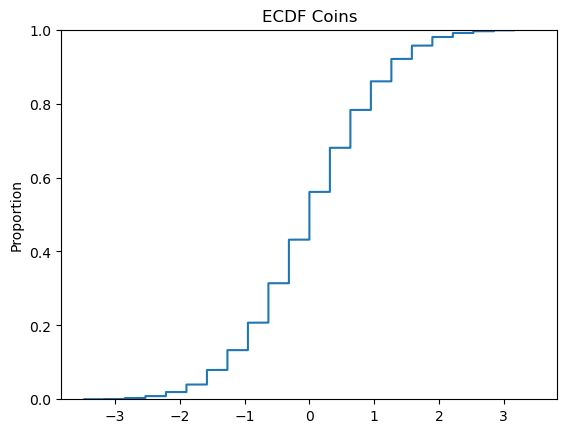

In [205]:
sns.ecdfplot(heads)
plt.title("ECDF Coins")

**5.** What distribution does this approach as n increases?

As n increases, the distribution approaches the binomial distribution. The overall S shape is similar to the normal distribution, but the data is discrete in this scenario so the steps in the ECDF do not smooth out, meaning it is a binomial ECDF. 

Text(0.5, 1.0, 'ECDF n = 1000')

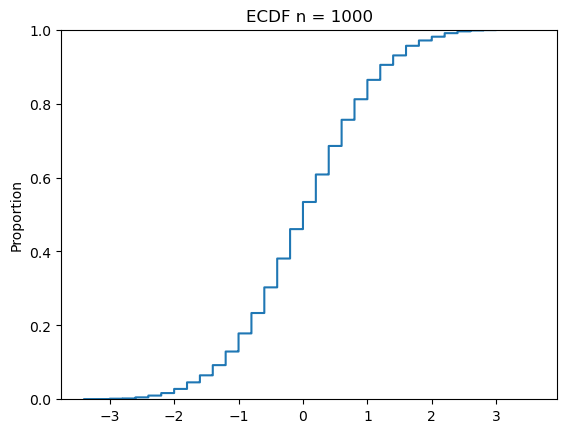

In [211]:
heads = []
p = 1/2
q = 1-p
b = 5_000
n = 100

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000")

Text(0.5, 1.0, 'Binomial ECDF')

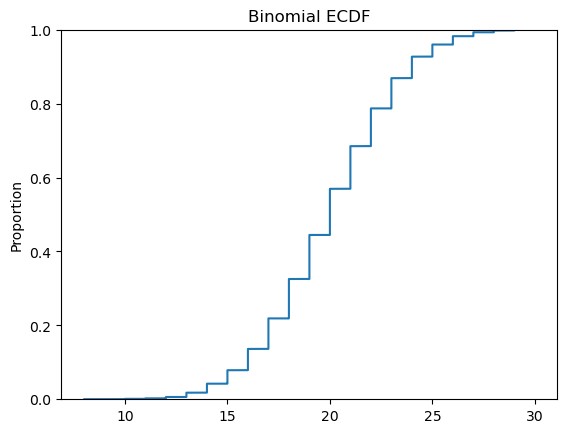

In [207]:
from scipy.stats import binom

n = 40
p = 1/2
b = 5_000

bin_vals = np.random.binomial(n = n, p = p, size = b)
sns.ecdfplot(bin_vals)
plt.title("Binomial ECDF")

**6. How do the results change as you adjust p?

When p is decreased to 1/4 compared to 1/2, nothing much changes in the ECDF other than the positive sidde of the range extending a little more to include 4. When p is increased to 3/4, the range favors negative numbers and has a slight extra hump in the curve in the middle. These occur because the computation formula changes for different values of p. When p is bigger, the total sum of heads increases, the expected value increases, the computed value decreases (denominator becomes larger), and vice versa for smaller p. 

Text(0.5, 1.0, 'ECDF n = 1000\np = 1/4')

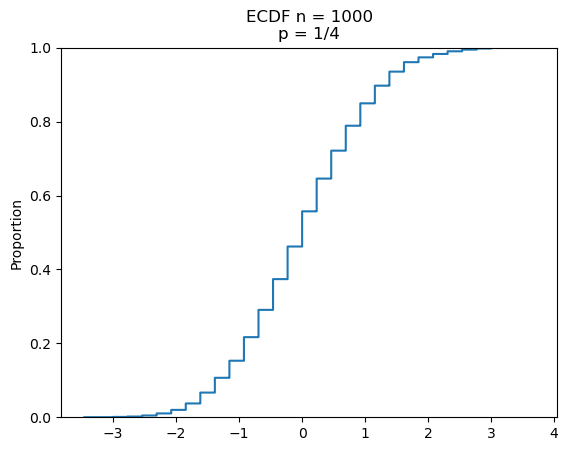

In [212]:
heads = []
p = 1/4
q = 1-p
b = 5_000
n = 100

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000\np = 1/4")

Text(0.5, 1.0, 'ECDF n = 1000\np = 3/4')

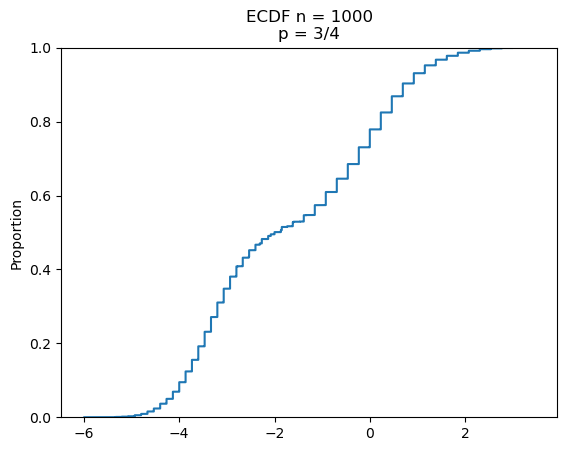

In [210]:
p = 3/4
for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000\np = 3/4")

****Q5****

**1.** Draw K = 20 values from Uniform[0,1]

In [219]:
K = 20
rng = np.random.default_rng()
values = rng.uniform(0, 1, size = K)

**2.** Sort them by size from smallest to largest

In [228]:
values = np.sort(values)


**3.** Record the largest value

In [232]:
max(values)

np.float64(0.9623661937733021)

**4.** Repeat n times and plot the ECDF